# 16 — Time from visit start to lock

Days between a first visit's `created_at` and `updated_at` for locked visits, compared against the rolling average for the same start month via `AVG() OVER (PARTITION BY start_month)`. Mirrors `docs/clientQueries.md` §3.3.

In [ ]:
import pandas as pd
from sqlalchemy import text
from db import get_engine

engine = get_engine()

In [2]:
query = """
WITH lock_times AS (
  SELECT
    visit_id,
    client_id,
    DATE_FORMAT(created_at, '%Y-%m-01') AS start_month,
    DATEDIFF(updated_at, created_at) AS days_to_lock
  FROM visits
  WHERE visit_type = '1' AND visit_is_locked = 1
)
SELECT
  visit_id,
  client_id,
  start_month,
  days_to_lock,
  ROUND(AVG(days_to_lock) OVER (PARTITION BY start_month), 1) AS avg_days_to_lock_that_month
FROM lock_times
ORDER BY start_month, days_to_lock;
"""

# text() routes this through SQLAlchemy's compiler instead of PyMySQL's raw
# `%`-mogrify, which otherwise chokes on the literal `%Y`/`%m` in DATE_FORMAT.
df = pd.read_sql(text(query), engine, parse_dates=["start_month"])
print(df)

    visit_id  client_id start_month  days_to_lock  avg_days_to_lock_that_month
0         14         40  2025-11-01            -7                         -0.7
1          1         37  2025-11-01             0                         -0.7
2         21         80  2025-11-01             0                         -0.7
3         20         22  2025-11-01             0                         -0.7
4         18         10  2025-11-01             0                         -0.7
5          2         44  2025-11-01             0                         -0.7
6         10        103  2025-11-01             2                         -0.7
7          3         64  2025-12-01             0                          0.0
8          4         33  2026-01-01             0                          6.7
9          5          6  2026-01-01             1                          6.7
10         6         24  2026-01-01            19                          6.7
11        11        102  2026-02-01            64   

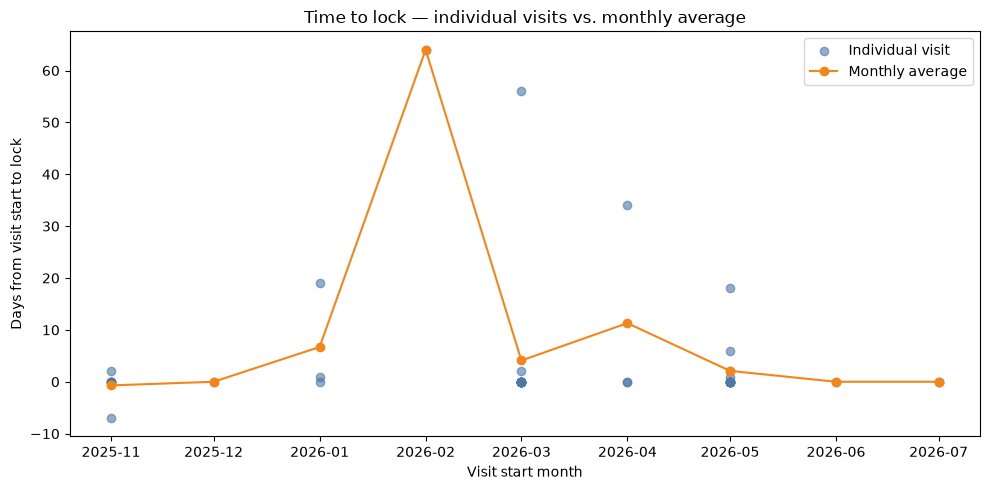

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

monthly_avg = df.drop_duplicates("start_month").sort_values("start_month")

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df["start_month"], df["days_to_lock"], color="#4C78A8", alpha=0.6, label="Individual visit")
ax.plot(
    monthly_avg["start_month"], monthly_avg["avg_days_to_lock_that_month"],
    color="#F58518", marker="o", label="Monthly average",
)
ax.set_xlabel("Visit start month")
ax.set_ylabel("Days from visit start to lock")
ax.set_title("Time to lock — individual visits vs. monthly average")
ax.legend()
fig.tight_layout()

os.makedirs("../assets/img", exist_ok=True)
fig.savefig("../assets/img/time_to_lock.png", dpi=150)
plt.show()